In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('TEPdata.csv')
print("Shape:", df.shape)
print("\nFault number distribution:")
print(df.groupby('faultNumber')['simulationRun'].nunique().rename('# time windows'))

# Reshape: one row per (faultNumber, simulationRun) time window
sensor_cols = [c for c in df.columns if c.startswith('xmeas_') or c.startswith('xmv_')]
print(f"\nSensor columns: {len(sensor_cols)}")

df = df.sort_values(['faultNumber', 'simulationRun', 'sample'])

def flatten_window(group):
    return pd.Series(group[sensor_cols].values.flatten())

print("Reshaping data into one row per time window (this may take ~1 min)...")
grouped = df.groupby(['faultNumber', 'simulationRun'], sort=False)
X_flat = grouped.apply(flatten_window).reset_index(drop=True)
y = grouped['faultNumber'].first().reset_index(drop=True)

print(f"\nX shape: {X_flat.shape}")
print(f"Class distribution:\n{y.value_counts().sort_index()}")

# Stratified Train / Test Split (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.30, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# # Train Logistic Regression
# print("\nTraining Logistic Regression...")
# lr_model = LogisticRegression(
#     solver='saga',
#     max_iter=1000,
#     C=1.0,
#     multi_class='multinomial',
#     random_state=42,
#     n_jobs=-1,
# )
# lr_model.fit(X_train_scaled, y_train)
# print("Training complete.")

# # Accuracy
# train_preds = lr_model.predict(X_train_scaled)
# test_preds = lr_model.predict(X_test_scaled)
# train_acc = accuracy_score(y_train, train_preds)
# test_acc = accuracy_score(y_test, test_preds)
# print(f"\nTrain Accuracy: {train_acc * 100:.2f}%")
# print(f"Test  Accuracy: {test_acc  * 100:.2f}%")

# # Confusion Matrix
# classes = sorted(y.unique())
# cm = confusion_matrix(y_test, test_preds, labels=classes)

# fig, ax = plt.subplots(figsize=(12, 10))
# ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
#     ax=ax, colorbar=True, cmap='Blues'
# )
# ax.set_title(f'Confusion Matrix — Test Set\n(Logistic Regression, Accuracy: {test_acc*100:.2f}%)', fontsize=14)
# ax.set_xlabel('Predicted Fault Number', fontsize=12)
# ax.set_ylabel('True Fault Number', fontsize=12)
# plt.tight_layout()
# plt.savefig('te_process_confusion_matrix.png', dpi=150)
# plt.show()
# print("Confusion matrix saved to te_process_confusion_matrix.png")

Training Random Forest...
Training complete.

Train Accuracy: 100.00%
Test  Accuracy: 80.27%


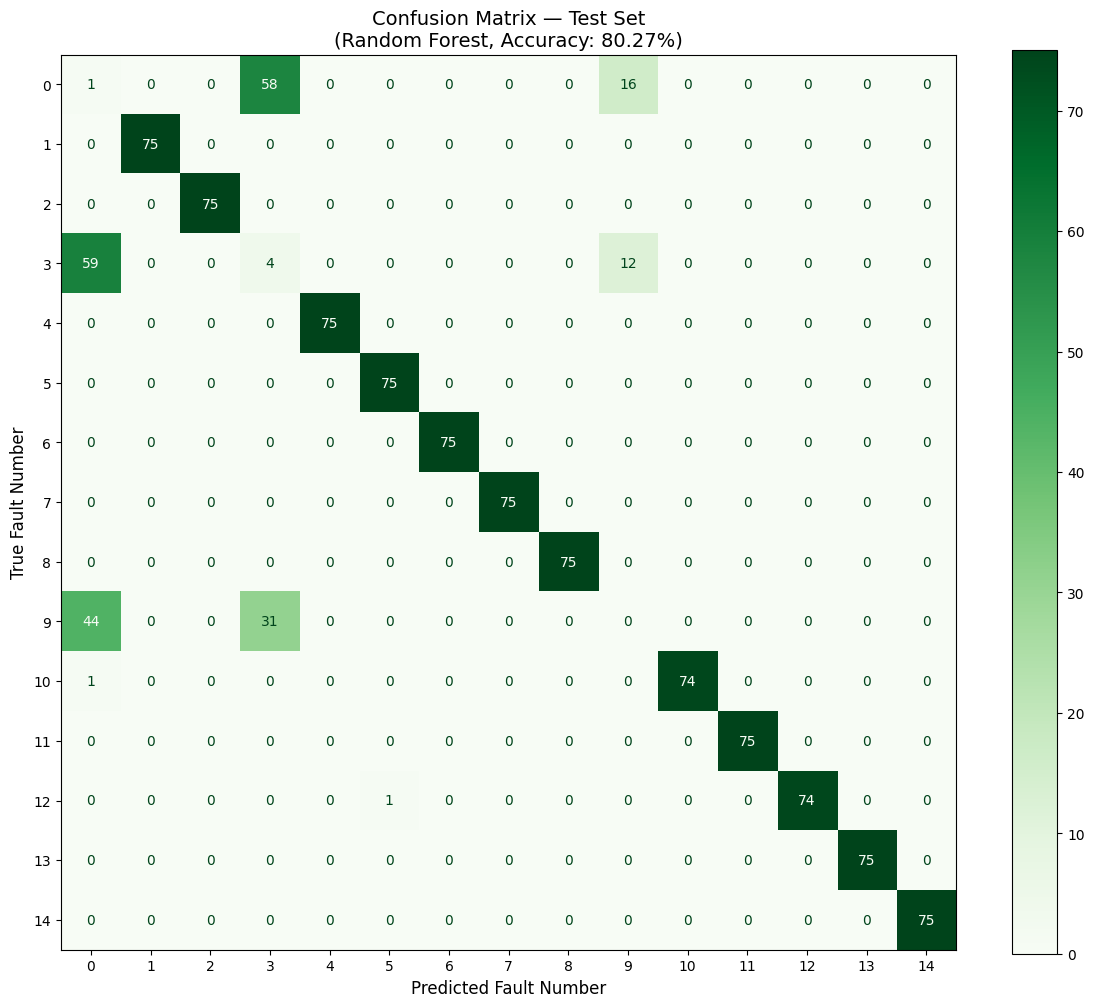

Confusion matrix saved to te_process_confusion_matrix_rf.png


In [6]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
print('Training complete.')

# Accuracy
rf_train_preds = rf_model.predict(X_train)
rf_test_preds  = rf_model.predict(X_test)
rf_train_acc = accuracy_score(y_train, rf_train_preds)
rf_test_acc  = accuracy_score(y_test,  rf_test_preds)
print(f'\nTrain Accuracy: {rf_train_acc * 100:.2f}%')
print(f'Test  Accuracy: {rf_test_acc  * 100:.2f}%')

# Confusion Matrix
classes = sorted(y.unique())
rf_cm = confusion_matrix(y_test, rf_test_preds, labels=classes)

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=classes).plot(
    ax=ax, colorbar=True, cmap='Greens'
)
ax.set_title(f'Confusion Matrix — Test Set\n(Random Forest, Accuracy: {rf_test_acc*100:.2f}%)', fontsize=14)
ax.set_xlabel('Predicted Fault Number', fontsize=12)
ax.set_ylabel('True Fault Number', fontsize=12)
plt.tight_layout()
plt.savefig('te_process_confusion_matrix_rf.png', dpi=150)
plt.show()
print('Confusion matrix saved to te_process_confusion_matrix_rf.png')


Training HistGradientBoosting...
Training complete.

Train Accuracy: 100.00%
Test  Accuracy: 81.42%


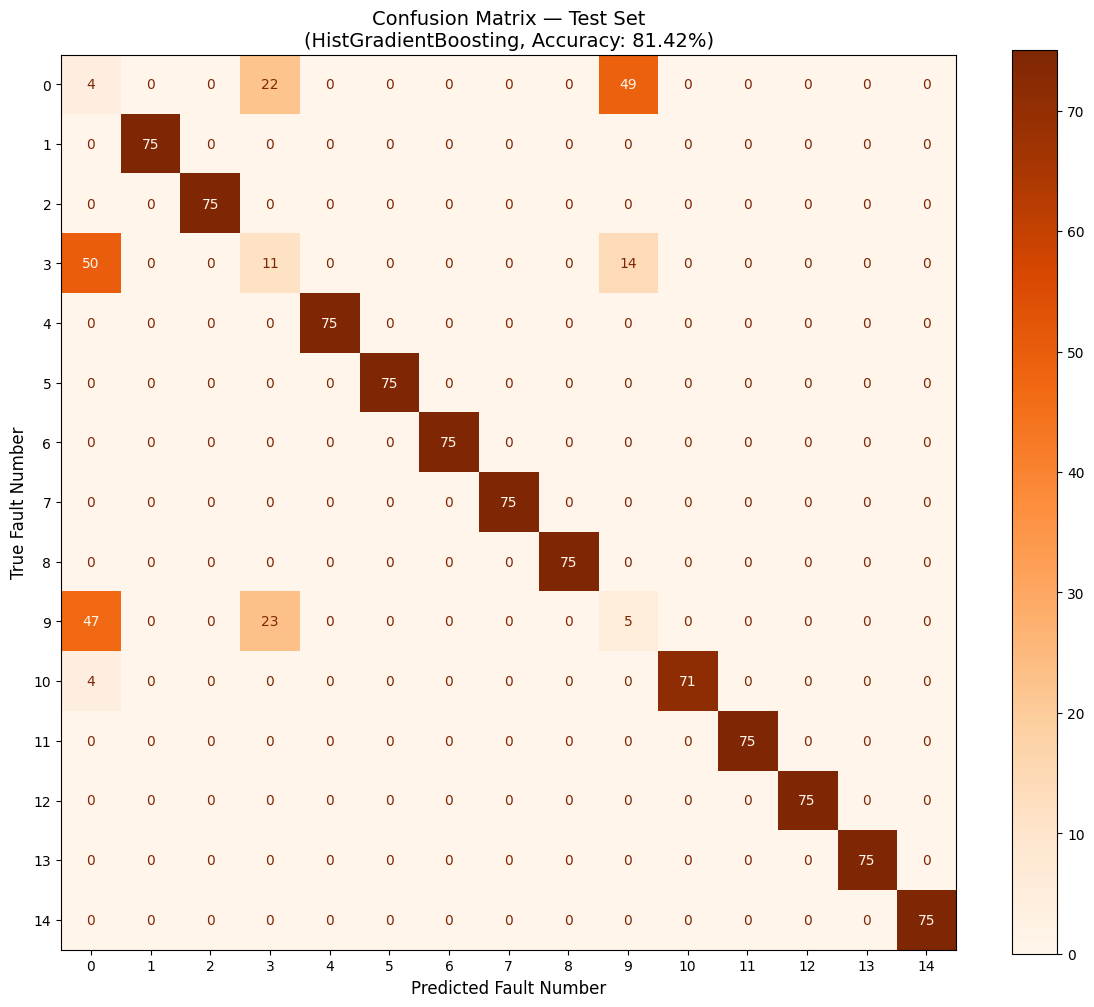

Confusion matrix saved to te_process_confusion_matrix_hgb.png


In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Train Histogram-based Gradient Boosting (fast, high accuracy)
print('Training HistGradientBoosting...')
hgb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.1,
    max_depth=None,
    random_state=42,
)
hgb_model.fit(X_train, y_train)
print('Training complete.')

# Accuracy
hgb_train_preds = hgb_model.predict(X_train)
hgb_test_preds  = hgb_model.predict(X_test)
hgb_train_acc = accuracy_score(y_train, hgb_train_preds)
hgb_test_acc  = accuracy_score(y_test,  hgb_test_preds)
print(f'\nTrain Accuracy: {hgb_train_acc * 100:.2f}%')
print(f'Test  Accuracy: {hgb_test_acc  * 100:.2f}%')

# Confusion Matrix
classes = sorted(y.unique())
hgb_cm = confusion_matrix(y_test, hgb_test_preds, labels=classes)

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(confusion_matrix=hgb_cm, display_labels=classes).plot(
    ax=ax, colorbar=True, cmap='Oranges'
)
ax.set_title(f'Confusion Matrix — Test Set\n(HistGradientBoosting, Accuracy: {hgb_test_acc*100:.2f}%)', fontsize=14)
ax.set_xlabel('Predicted Fault Number', fontsize=12)
ax.set_ylabel('True Fault Number', fontsize=12)
plt.tight_layout()
plt.savefig('te_process_confusion_matrix_hgb.png', dpi=150)
plt.show()
print('Confusion matrix saved to te_process_confusion_matrix_hgb.png')


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import skew, kurtosis

# --- Feature Engineering: statistical features per sensor per window ---
print('Extracting statistical features...')

def extract_features(group):
    vals = group[sensor_cols].values  # shape: (500, 52)
    feats = np.concatenate([
        vals.mean(axis=0),
        vals.std(axis=0),
        vals.min(axis=0),
        vals.max(axis=0),
        np.median(vals, axis=0),
        np.percentile(vals, 25, axis=0),
        np.percentile(vals, 75, axis=0),
        skew(vals, axis=0),
        kurtosis(vals, axis=0),
        np.polyfit(np.arange(len(vals)), vals, 1)[0],  # slope/trend per sensor
    ])
    return pd.Series(feats)

grouped = df.groupby(['faultNumber', 'simulationRun'], sort=False)
X_eng = grouped.apply(extract_features).reset_index(drop=True)
y_eng = grouped['faultNumber'].first().reset_index(drop=True)

print(f'Engineered feature matrix shape: {X_eng.shape}')  # (3750, 520)

# Stratified 70/30 split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_eng, y_eng, test_size=0.30, random_state=42, stratify=y_eng
)
print(f'Train: {X_tr.shape[0]} | Test: {X_te.shape[0]}')

# Train Random Forest on engineered features
print('\nTraining Random Forest on engineered features...')
rf_eng = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_eng.fit(X_tr, y_tr)
print('Training complete.')

# Accuracy
eng_train_acc = accuracy_score(y_tr, rf_eng.predict(X_tr))
eng_test_preds = rf_eng.predict(X_te)
eng_test_acc  = accuracy_score(y_te, eng_test_preds)
print(f'\nTrain Accuracy: {eng_train_acc * 100:.2f}%')
print(f'Test  Accuracy: {eng_test_acc  * 100:.2f}%')

# Confusion Matrix
classes = sorted(y_eng.unique())
eng_cm = confusion_matrix(y_te, eng_test_preds, labels=classes)

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(confusion_matrix=eng_cm, display_labels=classes).plot(
    ax=ax, colorbar=True, cmap='Purples'
)
ax.set_title(f'Confusion Matrix — Test Set\n(RF + Feature Engineering, Accuracy: {eng_test_acc*100:.2f}%)', fontsize=14)
ax.set_xlabel('Predicted Fault Number', fontsize=12)
ax.set_ylabel('True Fault Number', fontsize=12)
plt.tight_layout()
plt.savefig('te_process_confusion_matrix_rf_eng.png', dpi=150)
plt.show()
print('Confusion matrix saved to te_process_confusion_matrix_rf_eng.png')
